# Part 2: Flow Matching Parameterization

In [6]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [9]:
AVAILABLE_DATASETS = ("swiss_roll", "gaussians", "circles")
DIMS = (2, 8, 32)
PRED_LOSS = (("x", "x"), ("x", "v"), ("v", "x"), ("v", "v"))

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("res/part2")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_STEPS = 25000          # adjust to hit ~25k steps given your dataset size
STEPS = 50
BATCH = 1024
N_GEN = 2048           # samples to generate for visualization

### Helpers

In [10]:
def model_tag(dataset, D, pred, loss):
    return f"{dataset}_D{D}_{pred}pred_{loss}loss"


def train_one_config(dataset, D, pred_type, loss_type, device, n_steps=25_000):
    dataloader = get_dataloader(name=dataset, dim=D, batch_size=1024)
    model = JiM(hidden_dim=256, D=D).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    train_n_steps(model, dataloader, opt, device, n_steps, pred_type, loss_type)
    torch.save(model.state_dict(), MODEL_DIR / f"{model_tag(dataset, D, pred_type, loss_type)}.pt")
    return model


def generate_samples(model, D, pred_type, device, n=N_GEN):
    denoiser = Denoiser(model, steps=STEPS, D=D)
    return denoiser.generate(n, pred_type, device).cpu().numpy()


def get_ground_truth(dataset, D, n=N_GEN):
    loader = get_dataloader(name=dataset, dim=D, batch_size=n)
    return next(iter(loader))[:n].cpu().numpy()


def project_to_2d(samples, dataset, D):
    if D == 2:
        return samples
    loader = get_dataloader(name=dataset, dim=D, batch_size=1)
    return loader.dataset.to_2d(torch.from_numpy(samples)).numpy()


def plot_grid(dataset, device):
    """One figure per dataset: 4 rows (pred/loss combos) × 3 cols (D ∈ {2,8,32}).
    Each cell overlays generated samples (color) over ground truth (light gray)."""
    fig, axes = plt.subplots(
        len(PRED_LOSS), len(DIMS),
        figsize=(4 * len(DIMS), 4 * len(PRED_LOSS)),
        squeeze=False,
    )

    for row, (pred, loss) in enumerate(PRED_LOSS):
        for col, D in enumerate(DIMS):
            ax = axes[row, col]
            tag = model_tag(dataset, D, pred, loss)

            model = JiM(hidden_dim=256, D=D).to(device)
            model.load_state_dict(torch.load(MODEL_DIR / f"{tag}.pt", map_location=device))
            model.eval()

            gen = generate_samples(model, D, pred, device)
            gt = get_ground_truth(dataset, D)

            gen2d = project_to_2d(gen, dataset, D)
            gt2d = project_to_2d(gt, dataset, D)

            swd = sliced_wasserstein(gen2d, gt2d)
            ax.scatter(gt2d[:, 0],  gt2d[:, 1],  s=3, alpha=0.25, c="gray", label="ground truth")
            ax.scatter(gen2d[:, 0], gen2d[:, 1], s=3, alpha=0.55, c="C0",        label="generated")
            ax.set_title(f"{pred}-pred + {loss}-loss   D={D}", fontsize=11)
            ax.set_aspect("equal")
            ax.set_xticks([]); ax.set_yticks([])

            ax.text(0.02, 0.98, f"SWD = {swd:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                    edgecolor="none", alpha=0.8))

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 1.02), fontsize=11)
    fig.suptitle(f"Dataset: {dataset}", fontsize=14, y=1.05)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{dataset}_grid.png", dpi=150, bbox_inches="tight")
    plt.show()

def sliced_wasserstein(x, y, n_proj=64, seed=0):
    """Sliced Wasserstein-1 distance between two point clouds. Lower = closer."""
    rng = np.random.default_rng(seed)
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    dirs = rng.normal(size=(n_proj, x.shape[1])).astype(np.float64)
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    px = np.sort(x @ dirs.T, axis=0)              # (n, n_proj)
    py = np.sort(y @ dirs.T, axis=0)
    return float(np.mean(np.abs(px - py)))

### Training Loop

[skip] swiss_roll_D2_xpred_xloss already trained
[skip] swiss_roll_D2_xpred_vloss already trained
[skip] swiss_roll_D2_vpred_xloss already trained
[skip] swiss_roll_D2_vpred_vloss already trained
[skip] swiss_roll_D8_xpred_xloss already trained
[skip] swiss_roll_D8_xpred_vloss already trained
[skip] swiss_roll_D8_vpred_xloss already trained
[skip] swiss_roll_D8_vpred_vloss already trained
[skip] swiss_roll_D32_xpred_xloss already trained
[skip] swiss_roll_D32_xpred_vloss already trained
[skip] swiss_roll_D32_vpred_xloss already trained
[skip] swiss_roll_D32_vpred_vloss already trained
[skip] gaussians_D2_xpred_xloss already trained
[skip] gaussians_D2_xpred_vloss already trained
[skip] gaussians_D2_vpred_xloss already trained
[skip] gaussians_D2_vpred_vloss already trained
[skip] gaussians_D8_xpred_xloss already trained
[skip] gaussians_D8_xpred_vloss already trained
[skip] gaussians_D8_vpred_xloss already trained
[skip] gaussians_D8_vpred_vloss already trained
[skip] gaussians_D32_xpr

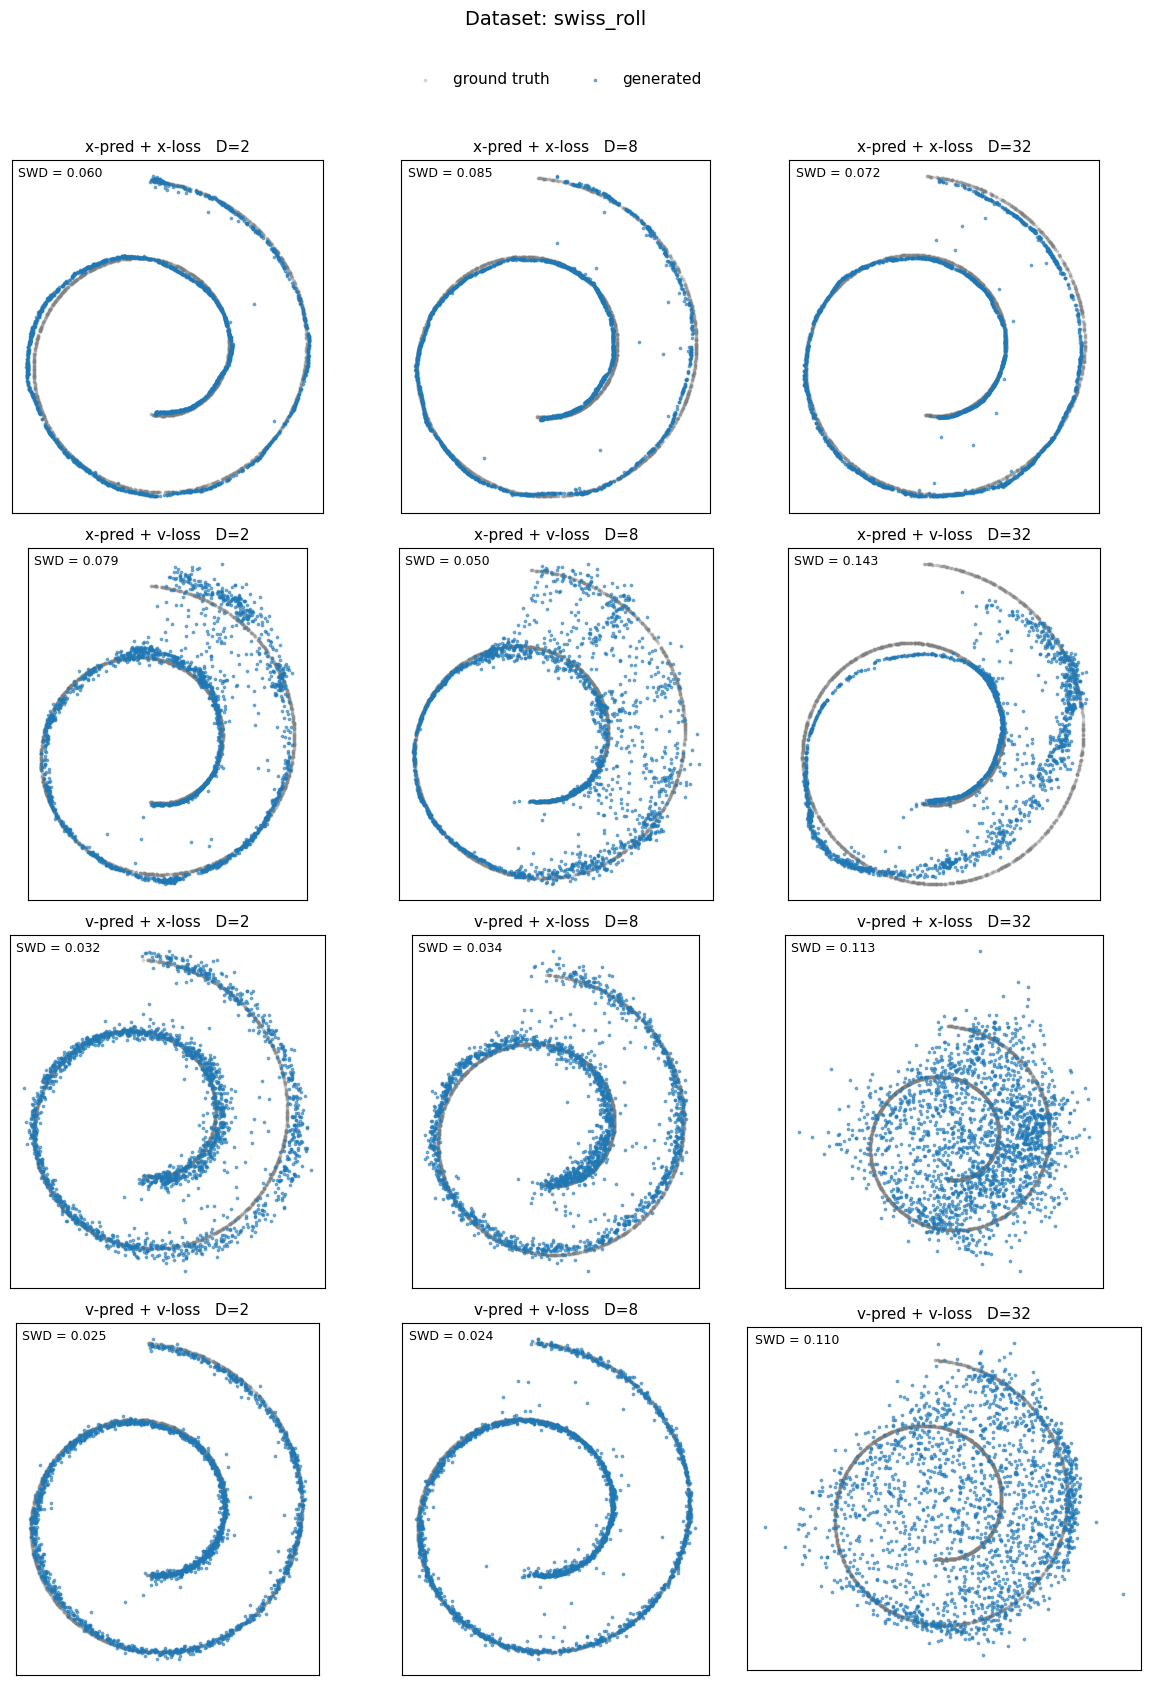

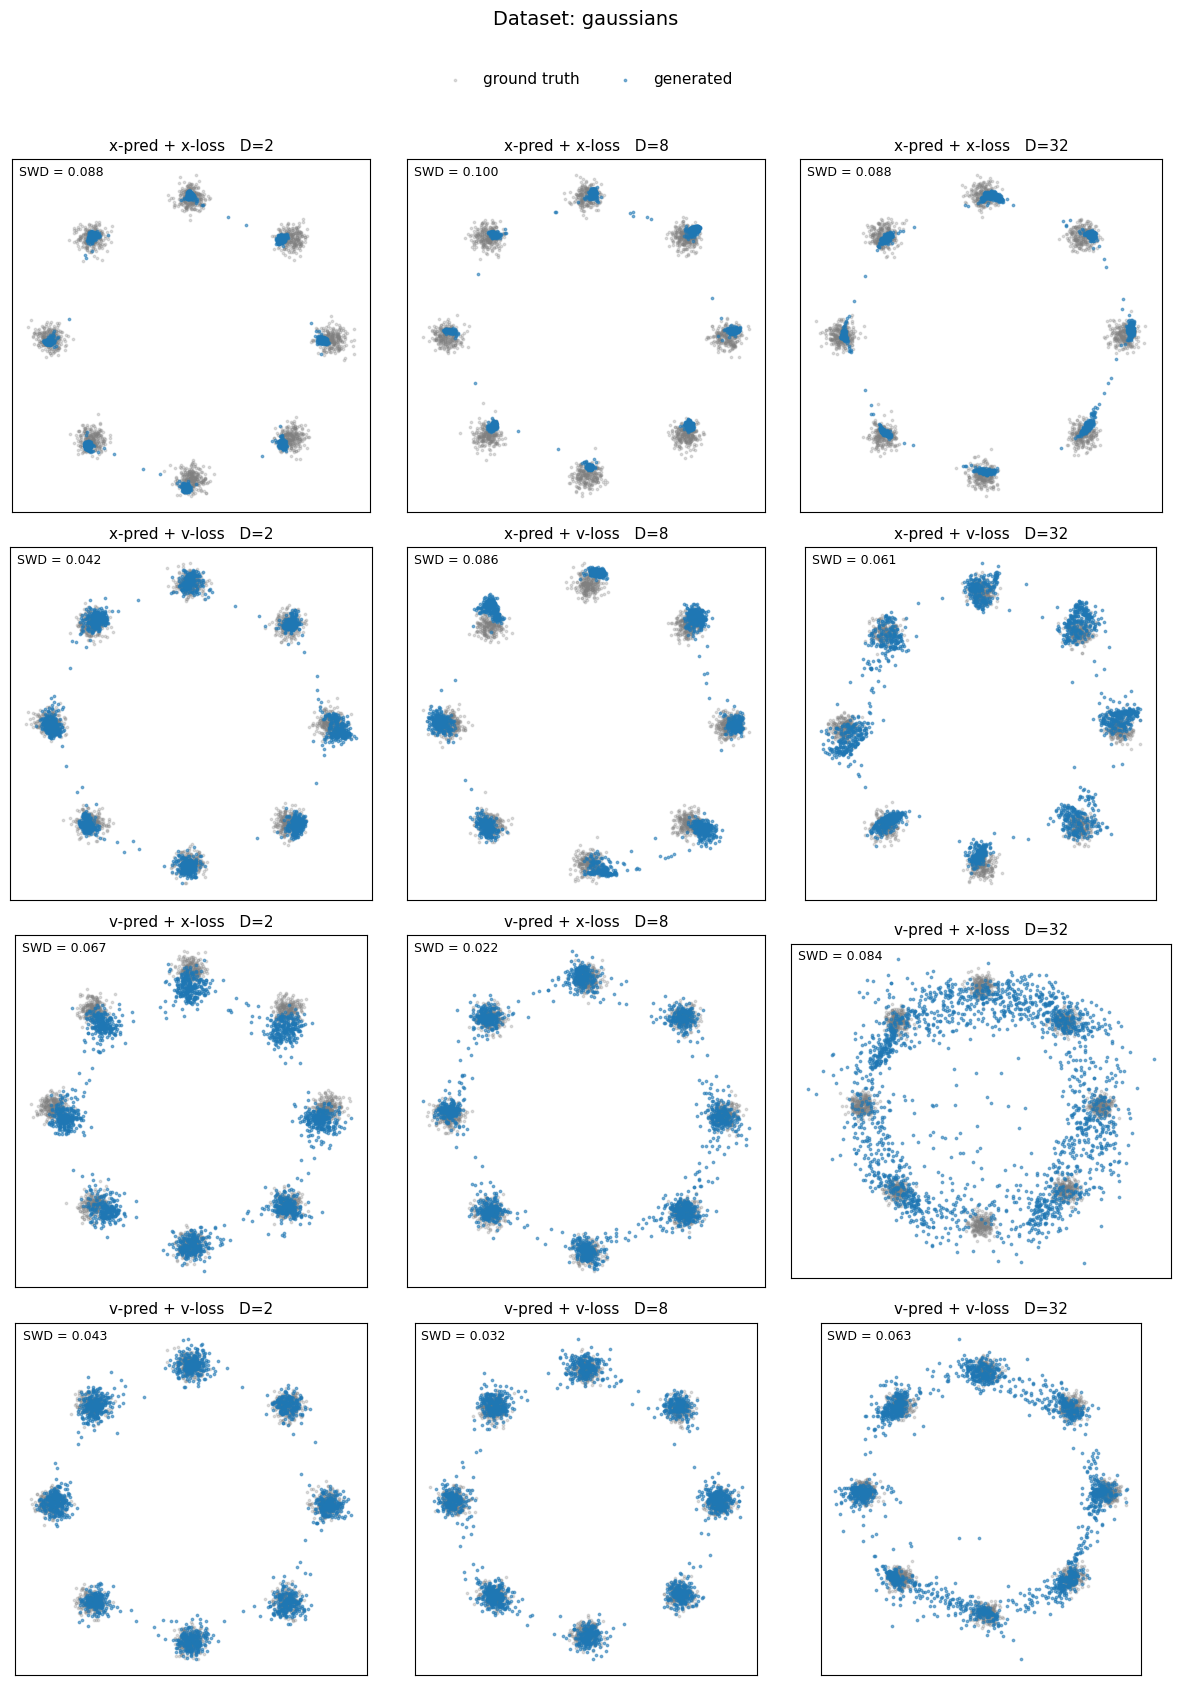

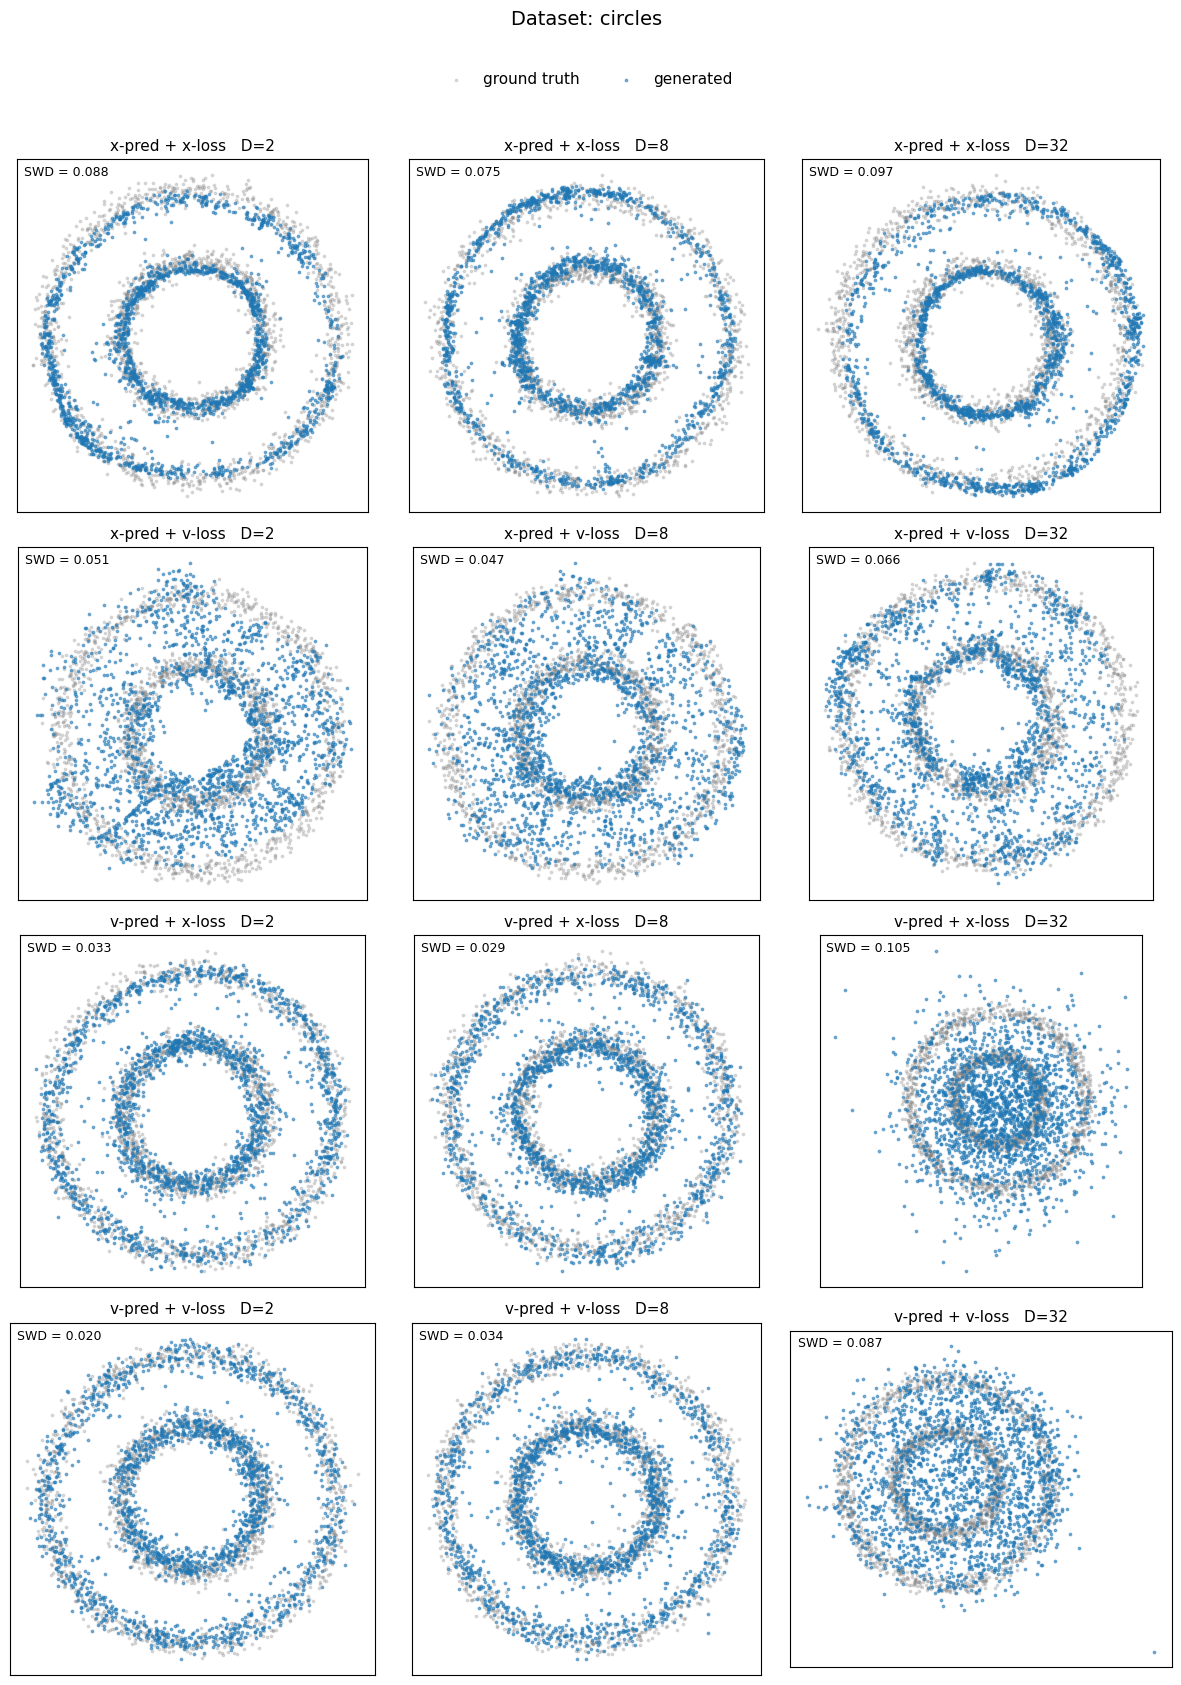

In [11]:
# === Train all 36 configs ===
device = "cuda" if torch.cuda.is_available() else "cpu"

for dataset in AVAILABLE_DATASETS:
    for D in DIMS:
        for pred, loss in PRED_LOSS:
            tag = model_tag(dataset, D, pred, loss)
            path = MODEL_DIR / f"{tag}.pt"
            if path.exists():
                print(f"[skip] {tag} already trained")
                continue
            print(f"[train] {tag}")
            train_one_config(dataset, D, pred, loss, device, TRAIN_STEPS)

# === Plot one grid per dataset ===
for dataset in AVAILABLE_DATASETS:
    plot_grid(dataset, device)

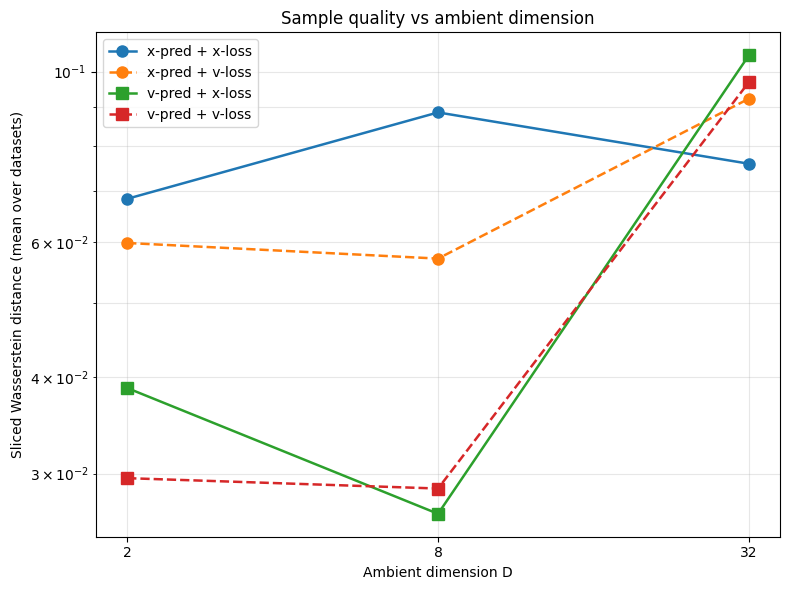

In [12]:
results = []                       # list of (pred, loss, D, dataset, swd)

for dataset in AVAILABLE_DATASETS:
    for D in DIMS:
        for pred, loss in PRED_LOSS:
            tag = model_tag(dataset, D, pred, loss)
            model = JiM(hidden_dim=256, D=D).to(device)
            model.load_state_dict(torch.load(MODEL_DIR / f"{tag}.pt", map_location=device))
            model.eval()

            gen   = generate_samples(model, D, pred, device)
            gt    = get_ground_truth(dataset, D)
            gen2d = project_to_2d(gen, dataset, D)
            gt2d  = project_to_2d(gt, dataset, D)

            swd = sliced_wasserstein(gen2d, gt2d)
            results.append((pred, loss, D, dataset, swd))

# Aggregate: mean SWD across datasets, per (pred, loss, D)
agg = {}                           # {(pred, loss): {D: mean_swd}}
for pred, loss, D, _ds, swd in results:
    agg.setdefault((pred, loss), {}).setdefault(D, []).append(swd)
agg = {k: {D: float(np.mean(v)) for D, v in d.items()} for k, d in agg.items()}

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
markers = {"x": "o", "v": "s"}
linestyles = {"x": "-", "v": "--"}

for (pred, loss), d_to_swd in agg.items():
    Ds = sorted(d_to_swd.keys())
    swds = [d_to_swd[D] for D in Ds]
    ax.plot(Ds, swds,
            marker=markers[pred], linestyle=linestyles[loss],
            label=f"{pred}-pred + {loss}-loss",
            linewidth=1.8, markersize=8)

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xticks(DIMS); ax.set_xticklabels(DIMS)
ax.set_xlabel("Ambient dimension D")
ax.set_ylabel("Sliced Wasserstein distance (mean over datasets)")
ax.set_title("Sample quality vs ambient dimension")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "swd_vs_dimension.png", dpi=150, bbox_inches="tight")
plt.show()